
# Robotic Arm Optimization Comparison

This notebook demonstrates how different optimization techniques affect the performance of a gradient descent-based robotic arm simulator.  
We explore and compare the following techniques:

- **Learning Rate Decay**
- **Energy Penalty (Regularization)**
- **Smoothness Penalty (Angle Change)**
- **Combinations of the above**

The final cost heatmaps illustrate how each approach converges toward minimizing the positional error of the arm's end-effector.


In [13]:
from src.optimizer import optimize_arm
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

sys.path.append(os.path.abspath(".."))
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
output_dir = os.path.join(project_root, "outputs", "optimized")
os.makedirs(output_dir, exist_ok=True)
print("Output path set to:", output_dir)

Output path set to: /Users/amit/Documents/smt/DS623-Optimotion/outputs/optimized



## Optimization Parameters

We will test several parameter combinations to understand their impact:

- **Default**: No penalties or decay.
- **Decay Only**: Reduces learning rate over time.
- **Energy Penalty Only**: Penalizes large joint angles.
- **Smoothness Only**: Penalizes large changes in joint angles.
- **Combinations**: Pairs and all techniques together.


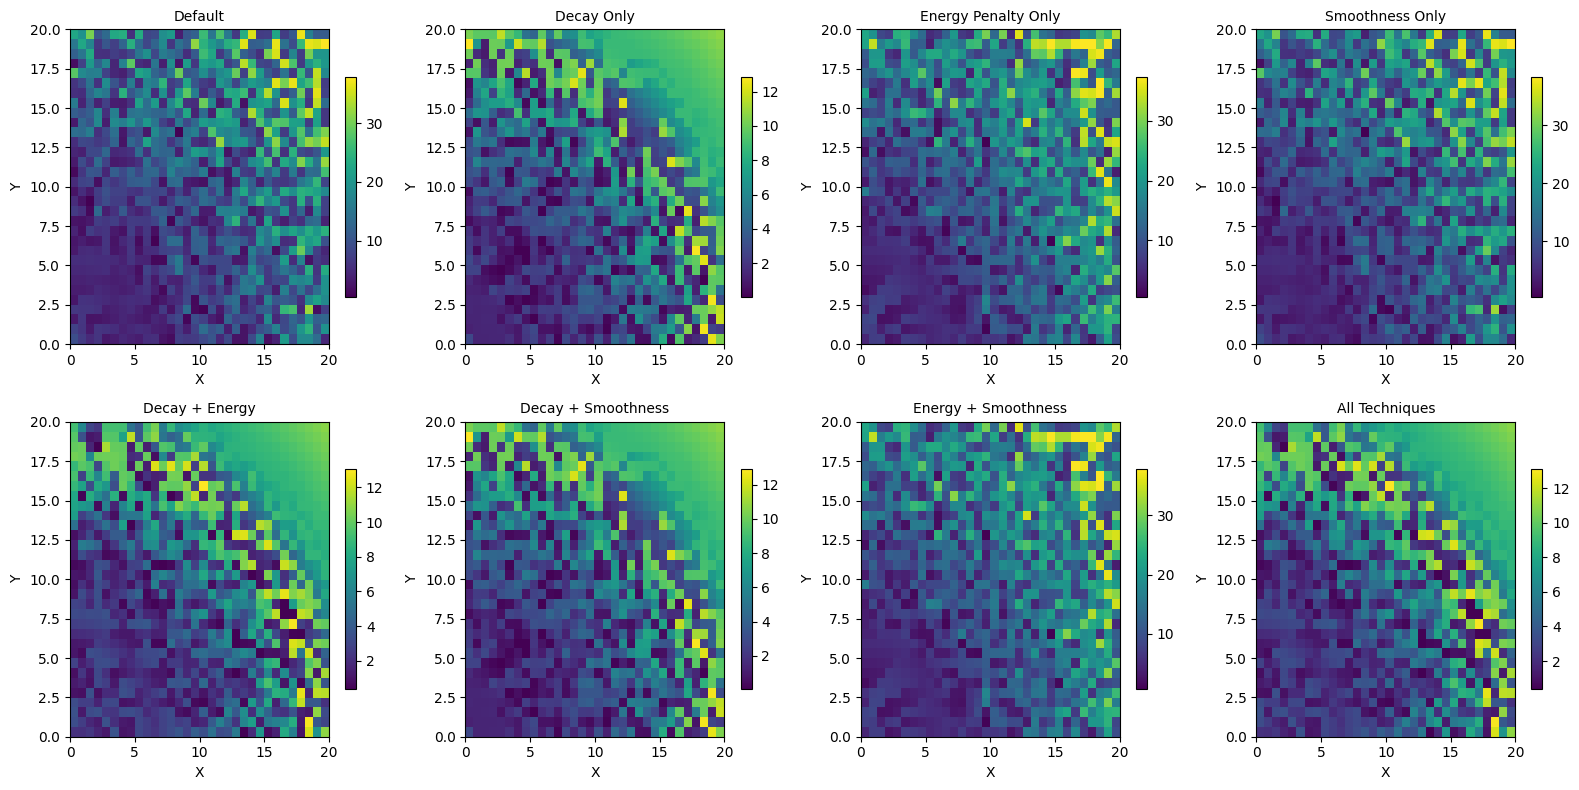

All heatmaps saved to: /Users/amit/Documents/smt/DS623-Optimotion/outputs/optimized


In [14]:
def run_optimized_simulation(x_range=None, y_range=None, step=None, num_instances=30,
                                link1_length=10.0, link2_length=10.0, iterations=50):
    max_reach = link1_length + link2_length
    if x_range is None:
        x_range = (0, max_reach)
    if y_range is None:
        y_range = (0, max_reach)

    if step is None:
        step = min((x_range[1] - x_range[0]) / num_instances, (y_range[1] - y_range[0]) / num_instances)

    x_vals = np.arange(x_range[0], x_range[1] + step, step)
    y_vals = np.arange(y_range[0], y_range[1] + step, step)

    configs = {
        "Default": {},
        "Decay Only": {"decay_rate": 0.05},
        "Energy Penalty Only": {"lambda_energy": 0.1},
        "Smoothness Only": {"lambda_smooth": 0.1},
        "Decay + Energy": {"decay_rate": 0.05, "lambda_energy": 0.1},
        "Decay + Smoothness": {"decay_rate": 0.05, "lambda_smooth": 0.1},
        "Energy + Smoothness": {"lambda_energy": 0.1, "lambda_smooth": 0.1},
        "All Techniques": {"decay_rate": 0.05, "lambda_energy": 0.1, "lambda_smooth": 0.1},
    }

    n = len(configs)
    ncols = 4
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 4 * nrows))
    axes = axes.flatten()

    for idx, (config_name, params) in enumerate(configs.items()):
        heatmap = np.zeros((len(y_vals), len(x_vals)))
        for i, y in enumerate(y_vals):
            for j, x in enumerate(x_vals):
                theta1_init = np.radians(20)
                theta2_init = np.radians(10)

                _, _, history = optimize_arm(
                    theta1_init, theta2_init,
                    x, y,
                    learning_rate=0.1,
                    iterations=iterations,
                    link1_length=link1_length,
                    link2_length=link2_length,
                    verbose=False,
                    **params
                )
                final_cost = history[-1][2]
                heatmap[i, j] = final_cost

        ax = axes[idx]
        cax = ax.imshow(heatmap, extent=(x_range[0], x_range[1], y_range[0], y_range[1]),
                        origin='lower', aspect='auto', cmap='viridis')
        ax.set_title(config_name, fontsize=10)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        fig.colorbar(cax, ax=ax, shrink=0.7)

    for k in range(idx + 1, len(axes)):
        fig.delaxes(axes[k])  # Remove unused subplots

    plt.tight_layout()
    plt.savefig(f"{output_dir}/heatmap_optimized_costs.png")
    plt.show()
    plt.close()

    print(f"All heatmaps saved to: {output_dir}")

run_optimized_simulation()